# 03 — Realized volatility, microstructure noise, and the tick

Sampling a noisy price more finely does not measure its volatility better.  With
$Y = X + \varepsilon$,

$$\mathbb{E}\,RV_n = IV + 2n\,\mathbb{E}[\varepsilon^2],$$

so the estimator diverges as the sampling tightens.  Three estimators fix it at
three different rates, and the rates are *measured* here rather than quoted.

Then the tick.  Robert and Rosenbaum's uncertainty-zones model says something
sharper than "discreteness is noise": it says where the efficient price *is*
when the traded one moves, which turns the tick grid from a nuisance into an
observation.

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hfx.viz import subplots, use_style, colour_for, tick_regime
from hfx.pipeline.results import panel, curves, curve, symbol_days
use_style()
P = panel(); C = curves()
DAY = "2019-01-30"
print(f"{len(P)} symbol-days, {P.symbol.nunique()} symbols, {P.date.nunique()} dates")

84 symbol-days, 12 symbols, 7 dates


## The rates, by Monte Carlo

Simulate a price whose integrated variance we chose, add noise, estimate, and
regress log RMSE on log $n$.  The theory says $-1/6$ for two-scale, $-1/4$ for
pre-averaging and $-1/5$ for the non-negative realized kernel -- the kernel pays
a rate for the guarantee that it never returns a negative variance.

In [2]:
from hfx.vol import estimators as ve

rng = np.random.default_rng(4)
IV, OMEGA = 4e-4, 1e-4
ns, reps = [4_000, 16_000, 64_000, 256_000], 120
rmse = {"two_scale": [], "pre_averaged": [], "realized_kernel": []}
for n in ns:
    acc = {k: [] for k in rmse}
    for _ in range(reps):
        x = np.concatenate(([0.0], np.cumsum(rng.normal(0, np.sqrt(IV / n), n))))
        y = x + rng.normal(0, OMEGA, n + 1)
        for name in rmse:
            acc[name].append(getattr(ve, name)(y))
    for name in rmse:
        rmse[name].append(np.sqrt(np.mean((np.array(acc[name]) - IV) ** 2)))
slopes = {k: np.polyfit(np.log(ns), np.log(v), 1)[0] for k, v in rmse.items()}
print(pd.DataFrame({"measured slope": slopes,
                    "theory": {"two_scale": -1/6, "pre_averaged": -1/4, "realized_kernel": -1/5}}).round(3))
assert abs(slopes["pre_averaged"] + 0.25) < 0.06

                 measured slope  theory
two_scale                -0.174  -0.167
pre_averaged             -0.241  -0.250
realized_kernel          -0.205  -0.200


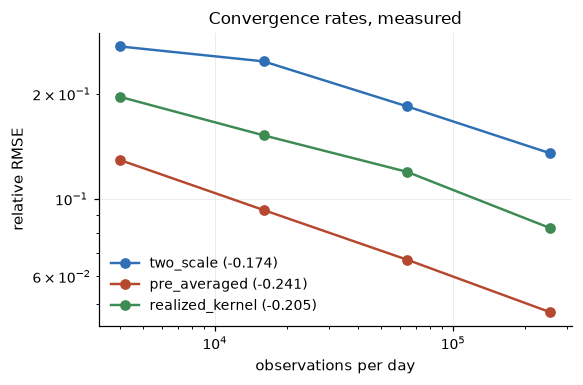

In [3]:
fig, ax = subplots(figsize=(5.4, 3.6))
for name, v in rmse.items():
    ax.loglog(ns, np.array(v) / IV, "o-", label=f"{name} ({slopes[name]:+.3f})")
ax.set_xlabel("observations per day"); ax.set_ylabel("relative RMSE")
ax.set_title("Convergence rates, measured"); ax.legend()
plt.tight_layout()

## The signature plot on real quotes

The same divergence, on the mid quote of four real symbols.  The horizontal
axis is the sampling step in seconds; the vertical axis is the realized variance
that step produces, as a multiple of the pre-averaged estimate of the same
day's integrated variance.

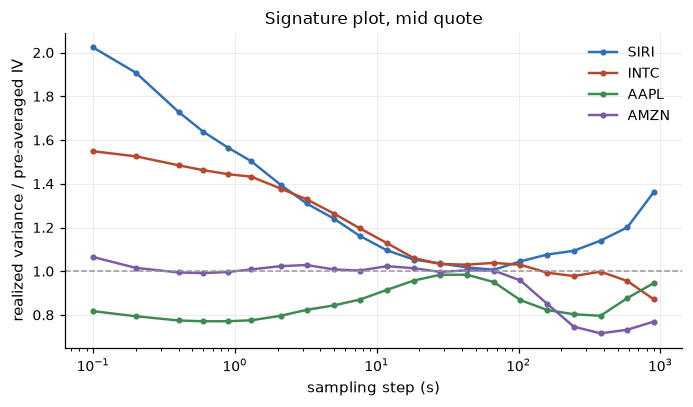

In [4]:
fig, ax = subplots(figsize=(6.4, 3.8))
for sym in ["SIRI", "INTC", "AAPL", "AMZN"]:
    steps = curve(C, sym, DAY, "signature_steps") / 10.0   # the grid is 100 ms
    rv = curve(C, sym, DAY, "signature_rv")
    iv = float(P[(P.symbol == sym) & (P.date == DAY)].preavg.iloc[0])
    ax.semilogx(steps, rv / iv, "o-", ms=3, label=sym)
ax.axhline(1.0, color="0.6", lw=1, ls="--")
ax.set_xlabel("sampling step (s)"); ax.set_ylabel("realized variance / pre-averaged IV")
ax.set_title("Signature plot, mid quote"); ax.legend()
plt.tight_layout()

## The tick grid, and the parameter that makes it readable

In the uncertainty-zones model the traded price moves from $\alpha k$ to
$\alpha(k\pm1)$ only once the efficient price has crossed a barrier
$(\tfrac12+\eta)\alpha$ away.  Just after a move the efficient price sits *on*
that barrier, so a further move in the same direction needs a distance
$\alpha$ and a reversal needs $2\eta\alpha$; the two-barrier argument gives

$$\frac{\mathbb{P}(\text{continuation})}{\mathbb{P}(\text{alternation})} = 2\eta
\quad\Longrightarrow\quad \hat\eta = \frac{N_c}{2N_a},$$

and, because the efficient price is known exactly at every price change,
$\hat X = P - d\,\alpha(\tfrac12-\eta)$ -- an integrated variance estimator with
the noise *removed* rather than averaged away.

In [5]:
from hfx.vol import uncertainty_zones as uz

rng = np.random.default_rng(9)
n, sigma, tick = 1_000_000, 0.30, 0.01
rows = []
for eta_true in [0.1, 0.2, 0.35, 0.5]:
    x = 50 + np.concatenate(([0.0], np.cumsum(rng.normal(0, sigma * np.sqrt(1 / n), n))))
    levels, _ = uz.simulate(x, tick, eta_true)
    eta_hat, nc, na = uz.estimate_eta(levels)
    rows.append({"eta": eta_true, "eta_hat": eta_hat, "changes": nc + na,
                 "IV_uz / IV": uz.integrated_variance(levels, tick, eta_hat) / sigma**2,
                 "RV_grid / IV": ve.realized_variance(levels * tick) / sigma**2,
                 "1 / (2 eta)": uz.variance_inflation(eta_true)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

 eta  eta_hat  changes  IV_uz / IV  RV_grid / IV  1 / (2 eta)
0.10    0.108     3881       0.936         4.313        5.000
0.20    0.215     2040       0.976         2.268        2.500
0.35    0.366     1230       1.001         1.368        1.429
0.50    0.517      877       1.008         0.976        1.000


Two things are being checked at once.  $\hat\eta$ recovers the parameter
that generated the path, and the realized variance of the *grid* price
overstates the integrated variance by $1/(2\eta)$ -- which is not a fit but an
optional-stopping identity: between two price changes the efficient price is a
martingale started on a barrier and absorbed at $+\alpha$ or $-2\eta\alpha$, so
it accumulates exactly $2\eta\alpha^2$ of quadratic variation.

In [6]:
u = P.groupby("symbol").agg(price=("price", "mean"), spread=("median_spread_ticks", "mean"),
                            eta=("eta", "mean"), eta_mid=("eta_mid", "mean"),
                            vol=("vol_preavg_pct", "mean"), vol_uz=("uz_vol_pct", "mean"),
                            measured=("grid_rv_over_uz", "mean"),
                            predicted=("variance_inflation_pred", "mean")).sort_values("spread")
u["vol_uz / vol"] = u.vol_uz / u.vol
u["inflation gap"] = (u.measured - u.predicted).abs()
print(u.round(3).to_string())
large = u[u.spread <= 1.2]
print(f"\nlarge-tick names: uncertainty-zone volatility within "
      f"{100 * (large['vol_uz / vol'] - 1).abs().max():.1f}% of the pre-averaged one")

           price  spread    eta  eta_mid    vol  vol_uz  measured  predicted  vol_uz / vol  inflation gap
symbol                                                                                                   
CSCO      49.214   1.000  0.706    0.611  0.945   0.999     0.730      0.713         1.056          0.017
INTC      54.482   1.000  0.709    0.591  1.073   1.102     0.733      0.711         1.027          0.022
MU        46.425   1.000  0.750    0.539  1.750   1.757     0.710      0.671         1.004          0.039
SIRI       6.380   1.000  0.519    0.399  1.214   1.178     1.138      1.105         0.971          0.033
MSFT     139.119   1.143  0.716    0.430  0.971   0.971     0.762      0.701         1.000          0.061
AAPL     231.725   2.286  0.870    0.521  1.176   1.212     0.736      0.588         1.031          0.148
NFLX     324.252  12.143  1.761    0.421  1.561   1.666     0.758      0.347         1.067          0.411
TSLA     344.886  15.571  0.981    0.403  2.03

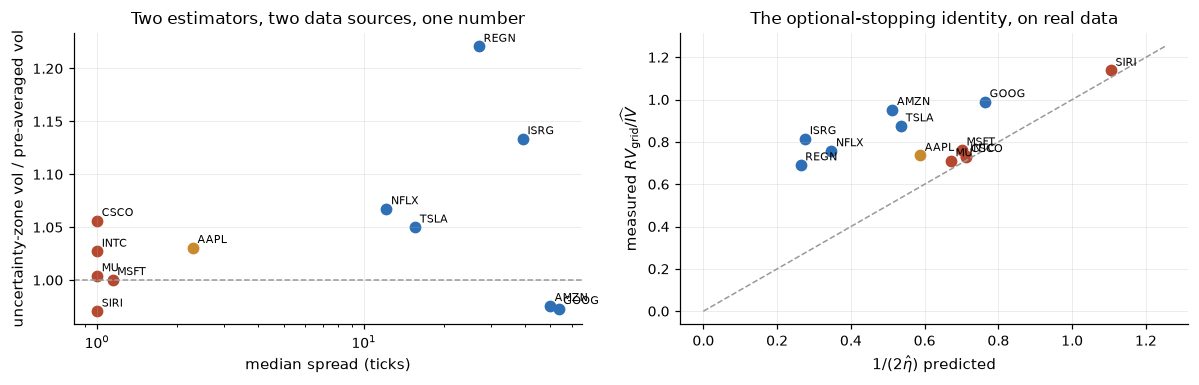

In [7]:
fig, axes = subplots(1, 2, figsize=(11, 3.6))
for sym, r in u.iterrows():
    axes[0].scatter(r.spread, r["vol_uz / vol"], color=colour_for(r.spread), s=45)
    axes[0].annotate(sym, (r.spread, r["vol_uz / vol"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    axes[1].scatter(r.predicted, r.measured, color=colour_for(r.spread), s=45)
    axes[1].annotate(sym, (r.predicted, r.measured), fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[0].set_xscale("log"); axes[0].axhline(1, color="0.6", ls="--", lw=1)
axes[0].set_xlabel("median spread (ticks)"); axes[0].set_ylabel("uncertainty-zone vol / pre-averaged vol")
axes[0].set_title("Two estimators, two data sources, one number")
lim = [0, max(u.predicted.max(), u.measured.max()) * 1.1]
axes[1].plot(lim, lim, color="0.6", lw=1, ls="--")
axes[1].set_xlabel(r"$1/(2\hat\eta)$ predicted"); axes[1].set_ylabel(r"measured $RV_{\rm grid}/\widehat{IV}$")
axes[1].set_title("The optional-stopping identity, on real data")
plt.tight_layout()

On the assets whose spread is pinned at one tick, an estimator that
uses only the *traded price on the tick grid* lands within a few percent of a
pre-averaged estimator built from the *quotes*.  They share no data and no
assumption beyond the model, so the agreement is a real check on both.

The measured $\eta$ is above $1/2$ on every symbol, which is outside the range
the model was written for -- $\eta>1/2$ means a reversal must travel further
than a continuation, so the printed price trends.  Two things push it up on a
Nasdaq tape.  The venue prints only part of the consolidated volume, so the
price moves between the trades it does print; and the estimator counts one-tick
changes, which stop being the relevant unit once the spread is several ticks
wide.  The value degrades in exactly that order across the panel, and the
identity in the right-hand panel fails at the same place.